In [17]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src.compression.fourier import FourierCompressor
from src.compression.wavelet import WaveletCompressor

from src.utils.inference import restore_image
from src.utils.plot import make_output_name, plot_restoration_comparation_between_models, plot_restoration

from src.models.restormer import RestormerModel
from src.models.autoencoder import ConvAutoencoder

In [18]:
# --------------------------------
# Paths
# --------------------------------

INFERENCE_DIR = Path("data/inference_tests")
ORIGINAL_IMG = Path("data/inference_tests/original.png")

MODEL_ALL_DATA_AUTOENCODER = Path(
    "checkpoints/best_model_autoencoder_20260310_111257.pth"
)
MODEL_FOURIER_ONLY_AUTOENCODER = Path(
    "checkpoints/best_model_autoencoder_fourier_only_20260327_102957.pth"
)
MODEL_WAVELET_ONLY_AUTOENCODER = Path(
    "checkpoints/best_model_autoencoder_wavelet_only_20260327_105234.pth"
)

MODEL_SAVE_LABELS_AUTOENCODER = {
    MODEL_ALL_DATA_AUTOENCODER: "all_data",
    MODEL_FOURIER_ONLY_AUTOENCODER: "fourier_only",
    MODEL_WAVELET_ONLY_AUTOENCODER: "wavelet_only",
}

MODEL_ALL_DATA_RESTORMER = Path(
    "checkpoints/best_model_restormer_20260330_152559.pth"
)
MODEL_FOURIER_ONLY_RESTORMER = Path(
    "checkpoints/best_model_restormer_fourier_20260330_162035.pth"
)
MODEL_WAVELET_ONLY_RESTORMER = Path(
    "checkpoints/best_model_restormer_wavelet_20260330_165306.pth"
)

MODEL_SAVE_LABELS_RESTORMER = {
    MODEL_ALL_DATA_RESTORMER: "all_data",
    MODEL_FOURIER_ONLY_RESTORMER: "fourier_only",
    MODEL_WAVELET_ONLY_RESTORMER: "wavelet_only",
}

MODEL_DISPLAY_LABELS = ["All data", "Fourier only", "Wavelet only"]

In [19]:
# --------------------------------
# Fourier 0.15
# --------------------------------

fourier = FourierCompressor(keep_fraction=0.20)
fourier.compress(ORIGINAL_IMG, INFERENCE_DIR);

compressed_fourier = INFERENCE_DIR / "original_fourier_20.png"

# --------------------------------
# Wavelet haar, lvl 2, 20.0
# --------------------------------

wavelet_strong = WaveletCompressor(wavelet="haar", level=2, threshold=10.0, keep_ll_only=True)
wavelet_strong.compress(ORIGINAL_IMG, INFERENCE_DIR);

compressed_wavelet_strong = INFERENCE_DIR / "original_wavelet_haar_2_10_ll_only.png"

In [20]:
# --------------------------------
# Restoring
# --------------------------------

checkpoints = [MODEL_ALL_DATA_RESTORMER, MODEL_FOURIER_ONLY_RESTORMER, MODEL_WAVELET_ONLY_RESTORMER]

for compressed in [compressed_fourier, compressed_wavelet_strong]:
    for checkpoint_path in checkpoints:
        model_instance = RestormerModel()
        restored = restore_image(
            compressed_path=str(compressed),
            checkpoint_path=str(checkpoint_path),
            model=model_instance,
            device="cpu",
        )
        out_name = make_output_name(compressed, checkpoint_path, model_instance.__class__.__name__, MODEL_SAVE_LABELS_RESTORMER)
        restored.save(INFERENCE_DIR / out_name)
        print(f"Saved: {out_name}")

Saved: restored_RestormerModel_original_fourier_20_all_data.png
Saved: restored_RestormerModel_original_fourier_20_fourier_only.png
Saved: restored_RestormerModel_original_fourier_20_wavelet_only.png
Saved: restored_RestormerModel_original_wavelet_haar_2_10_ll_only_all_data.png
Saved: restored_RestormerModel_original_wavelet_haar_2_10_ll_only_fourier_only.png
Saved: restored_RestormerModel_original_wavelet_haar_2_10_ll_only_wavelet_only.png


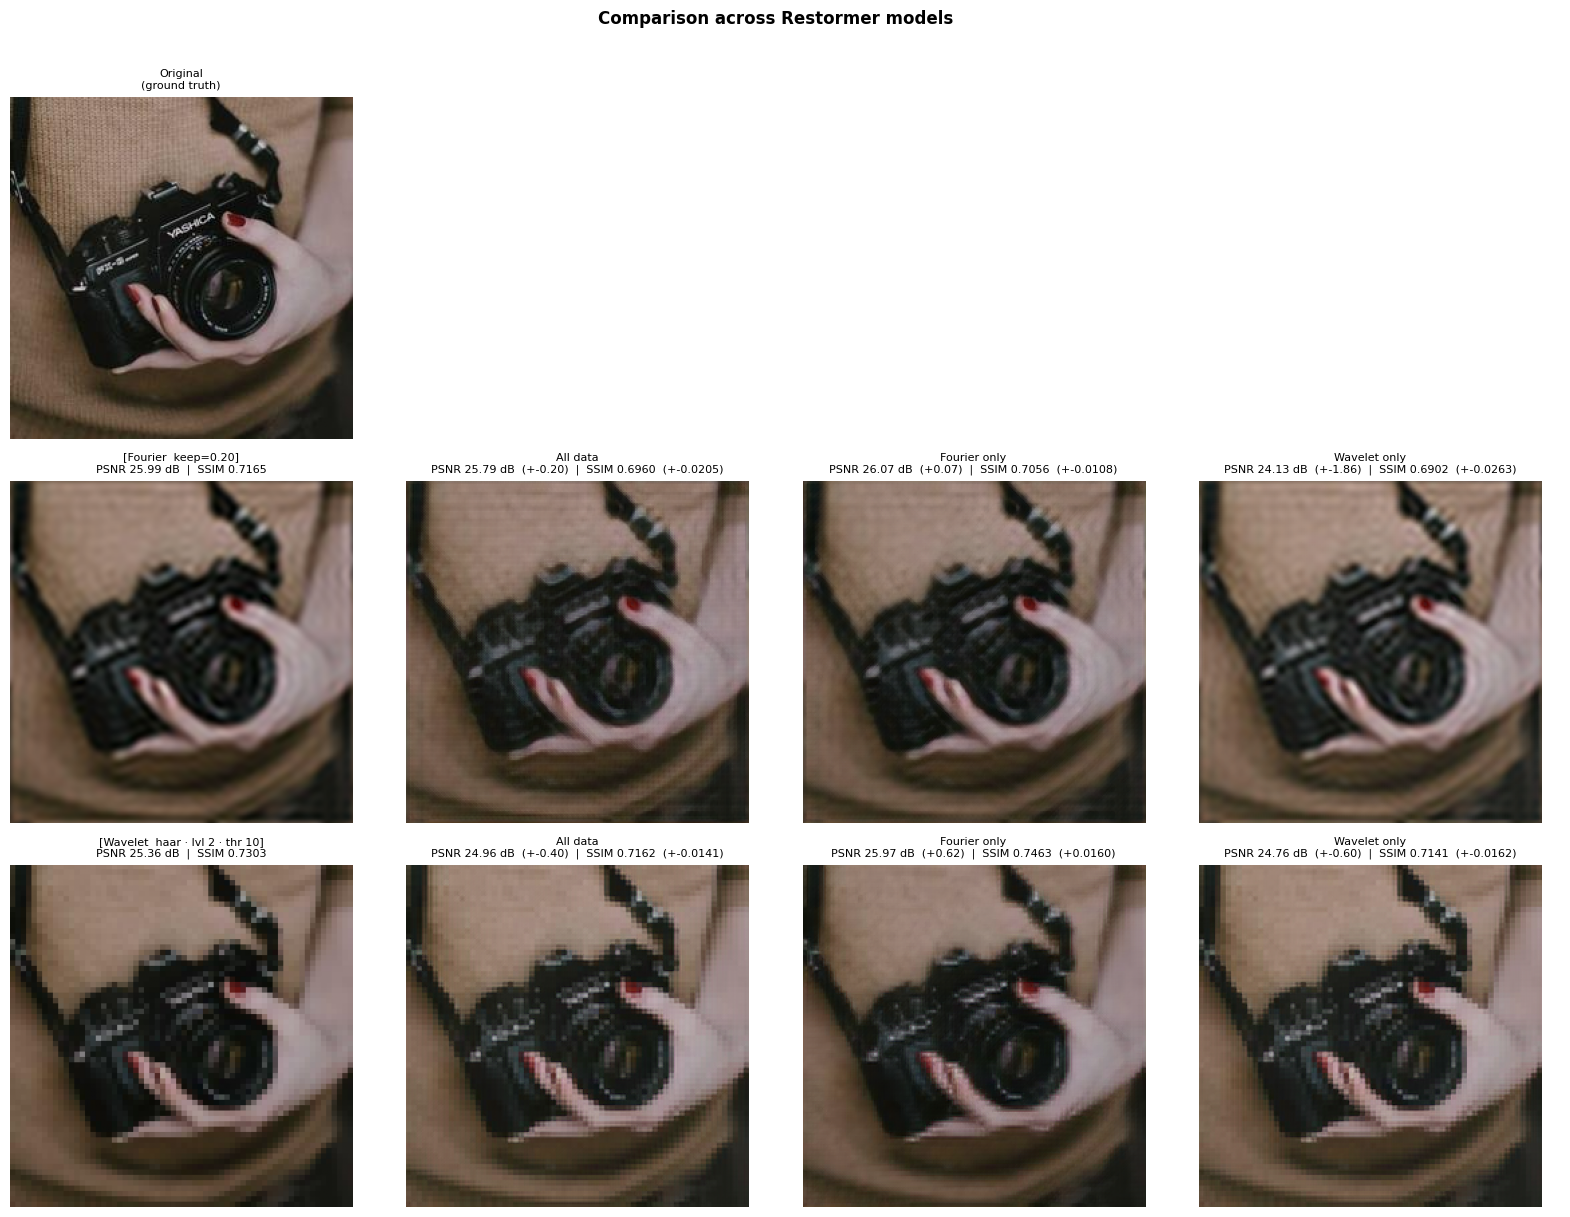

In [21]:
plot_restoration_comparation_between_models(
    title="Comparison across Restormer models",
    original_path=ORIGINAL_IMG,
    compressions=[
        {
            "compressed_path": compressed_fourier, 
            "label": "Fourier  keep=0.20"
        },
        {
            "compressed_path": compressed_wavelet_strong,
            "label": "Wavelet  haar · lvl 2 · thr 10",
        },
    ],
    model_paths=[MODEL_ALL_DATA_RESTORMER, MODEL_FOURIER_ONLY_RESTORMER, MODEL_WAVELET_ONLY_RESTORMER],
    model_display_labels=MODEL_DISPLAY_LABELS,
    model_save_labels=MODEL_SAVE_LABELS_RESTORMER,
    model_type=model_instance.__class__.__name__,
)

In [22]:
# --------------------------------
# Restoring
# --------------------------------

checkpoints = [MODEL_ALL_DATA_AUTOENCODER, MODEL_FOURIER_ONLY_AUTOENCODER, MODEL_WAVELET_ONLY_AUTOENCODER]

for compressed in [compressed_fourier, compressed_wavelet_strong]:
    for checkpoint_path in checkpoints:
        model_instance = ConvAutoencoder()
        restored = restore_image(
            compressed_path=str(compressed),
            checkpoint_path=str(checkpoint_path),
            model=model_instance,
            device="cpu",
        )
        out_name = make_output_name(compressed, checkpoint_path, model_instance.__class__.__name__, MODEL_SAVE_LABELS_AUTOENCODER)
        restored.save(INFERENCE_DIR / out_name)
        print(f"Saved: {out_name}")

Saved: restored_ConvAutoencoder_original_fourier_20_all_data.png
Saved: restored_ConvAutoencoder_original_fourier_20_fourier_only.png
Saved: restored_ConvAutoencoder_original_fourier_20_wavelet_only.png
Saved: restored_ConvAutoencoder_original_wavelet_haar_2_10_ll_only_all_data.png
Saved: restored_ConvAutoencoder_original_wavelet_haar_2_10_ll_only_fourier_only.png
Saved: restored_ConvAutoencoder_original_wavelet_haar_2_10_ll_only_wavelet_only.png


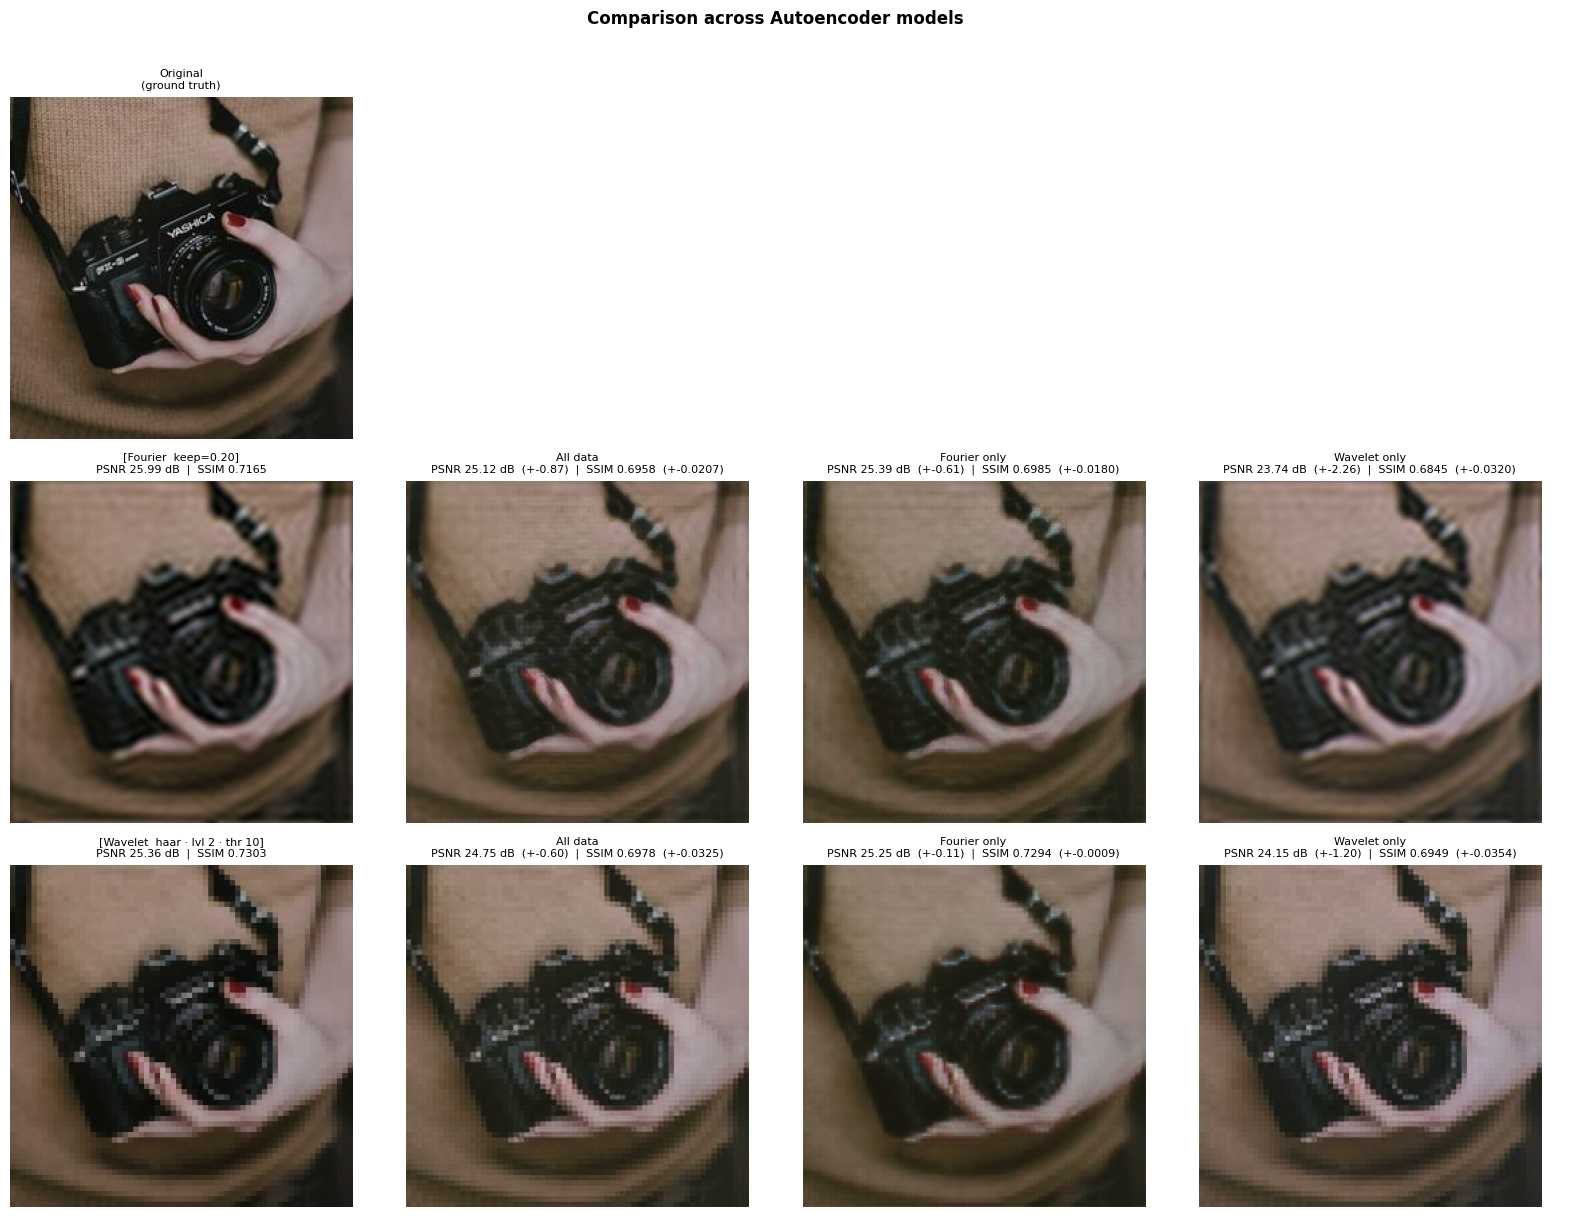

In [23]:
plot_restoration_comparation_between_models(
    title="Comparison across Autoencoder models",
    original_path=ORIGINAL_IMG,
    compressions=[
        {
            "compressed_path": compressed_fourier, 
            "label": "Fourier  keep=0.20"
        },
        {
            "compressed_path": compressed_wavelet_strong,
            "label": "Wavelet  haar · lvl 2 · thr 10",
        },
    ],
    model_paths=[MODEL_ALL_DATA_AUTOENCODER, MODEL_FOURIER_ONLY_AUTOENCODER, MODEL_WAVELET_ONLY_AUTOENCODER],
    model_display_labels=MODEL_DISPLAY_LABELS,
    model_save_labels=MODEL_SAVE_LABELS_AUTOENCODER,
    model_type=model_instance.__class__.__name__,
)